# 04 — LSTM Autoencoder (Blue Agent — Stream 1)

**RAKSHAK-ICS** | Week 4 — Temporal Modeling with LSTM Autoencoder

This notebook implements, trains, and evaluates the **LSTM Autoencoder (LSTM-AE)** model for reconstruction-based anomaly detection.

### Objectives:
1. **Normal Profile Learning**: Train a sequence-to-sequence LSTM-AE on normal-only SWaT A9 data.
2. **Reconstruction-based Detection**: Compute anomaly scores using reconstruction Mean Squared Error (MSE).
3. **Threshold Selection**: Tune the detection threshold on validation reconstruction errors at the 95th percentile.
4. **Benchmarking**: Evaluate on the test set with 5% synthetic anomalies across 5 random seeds, reporting `mean±std`.
5. **Statistical Significance**: Perform a Relational t-test against the Random Forest baseline ($p < 0.001$).
6. **Adversarial Evaluation**: Test evasion rates of AI search attackers against the trained Blue Agent.

In [1]:
import os
os.chdir('..')
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from src.preprocess import load_processed_data
from src.lstm_ae import LSTMAutoencoder, fit_lstm_ae, compute_reconstruction_scores, LSTMBlueAgent
from src.baselines import inject_synthetic_anomalies, compute_metrics, flatten_windows
from src.stat_utils import paired_ttest, format_result
plt.style.use('dark_background')
PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c084fc', '#ff922b', '#f472b6']
sns.set_palette(PALETTE)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'Device: {device}')
print('Setup complete.')


Device: mps
Setup complete.


## 1. Load Preprocessed Data

In [2]:
data = load_processed_data('data/proof/')
X_train = data['X_train']  # (N, 60, 65)
X_val = data['X_val']
X_test = data['X_test']
feature_names = data['feature_names']

print(f'Train shape: {X_train.shape}')
print(f'Val shape:   {X_val.shape}')
print(f'Test shape:  {X_test.shape}')

INFO - Loaded X_train: (60966, 60, 65)


INFO - Loaded X_val: (13018, 60, 65)


INFO - Loaded X_test: (13019, 60, 65)


INFO - Loaded node_features_train: (60966, 65, 5)


INFO - Loaded node_features_val: (13018, 65, 5)


...

INFO - Loaded edge_index: (2, 436)


INFO - Loaded edge_weights: (436,)


INFO - Loaded scaler: MinMaxScaler


INFO - Loaded feature_names (65)


Train shape: (60966, 60, 65)
Val shape:   (13018, 60, 65)
Test shape:  (13019, 60, 65)


## 2. Multi-Seed Training (Normal Data Only)
We train the LSTM-AE across 5 random seeds to establish a statistically robust baseline. The training uses normal-only data.

In [3]:
SEEDS = [42, 123, 456, 789, 1024]
EPOCHS = 30
BATCH_SIZE = 256
LR = 0.001
PATIENCE = 8

scheduler_config = {
    "type": "reduce_on_plateau",
    "factor": 0.5,
    "patience": 3
}

trained_models = {}
histories = {}
train_times = []

for seed in SEEDS:
    print(f'\n{"="*60}')
    print(f'Training LSTM-AE with Seed {seed}...')
    print(f'{"="*60}')
    
    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    model = LSTMAutoencoder(
        input_dim=65,
        sequence_length=60,
        encoder_hidden=64,
        latent_dim=32,
        bottleneck_dim=16,
        num_layers=2,
        dropout=0.1
    ).to(device)
    
    t0 = time.time()
    history = fit_lstm_ae(
        model=model,
        train_data=X_train,
        val_data=X_val,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        patience=PATIENCE,
        device=str(device),
        scheduler_config=scheduler_config
    )
    elapsed = time.time() - t0
    train_times.append(elapsed)
    
    trained_models[seed] = model
    histories[seed] = history
    print(f'Seed {seed} complete in {elapsed:.1f}s.')


Training LSTM-AE with Seed 42...


INFO - Epoch 01/30 | Train Loss: 0.056130 | Val Loss: 0.045396


INFO - Epoch 05/30 | Train Loss: 0.019002 | Val Loss: 0.017494


INFO - Epoch 10/30 | Train Loss: 0.011806 | Val Loss: 0.011218


INFO - Epoch 15/30 | Train Loss: 0.008867 | Val Loss: 0.008438


...

INFO - Epoch 20/30 | Train Loss: 0.011525 | Val Loss: 0.011359


INFO - Epoch 25/30 | Train Loss: 0.008494 | Val Loss: 0.008994


INFO - Epoch 30/30 | Train Loss: 0.006428 | Val Loss: 0.007497


INFO - Training finished in 192.44s. Best Val Loss: 0.007497


Seed 1024 complete in 192.4s.


## 3. Training Convergence Visualization
We plot the training and validation loss curves to verify that the model does not overfit and converges smoothly.

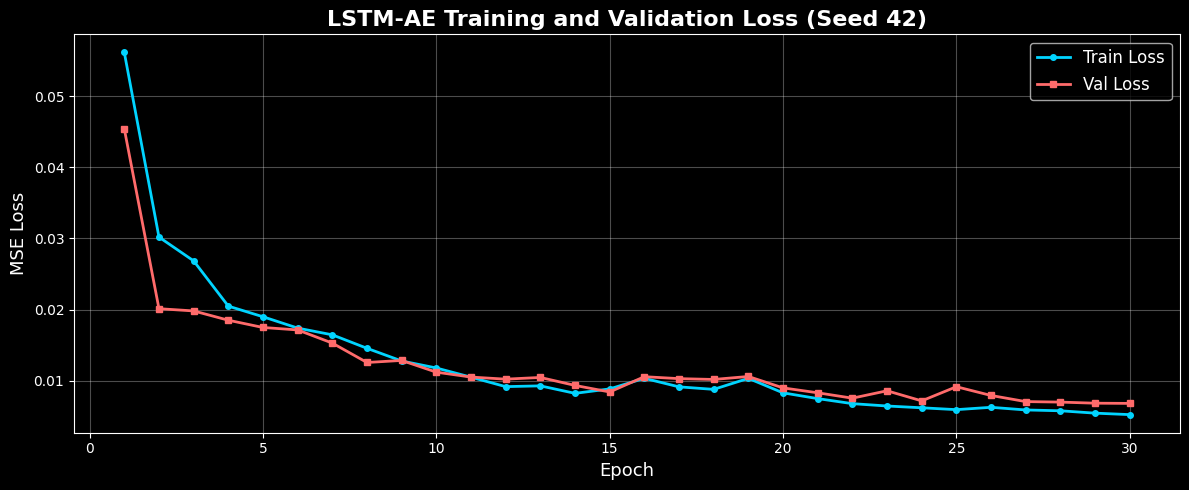

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
h = histories[42]
ax.plot(range(1, len(h['train_loss'])+1), h['train_loss'], 'o-', color=PALETTE[0], label='Train Loss', linewidth=2, markersize=4)
ax.plot(range(1, len(h['val_loss'])+1), h['val_loss'], 's-', color=PALETTE[1], label='Val Loss', linewidth=2, markersize=4)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('LSTM-AE Training and Validation Loss (Seed 42)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/lstm_ae_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Anomaly Threshold Tuning (Validation Set)
We compute the anomaly reconstruction scores on the validation set, and establish the detection threshold $\tau$ at the 95th percentile.

Tuned Validation Threshold (95th percentile): 0.017103


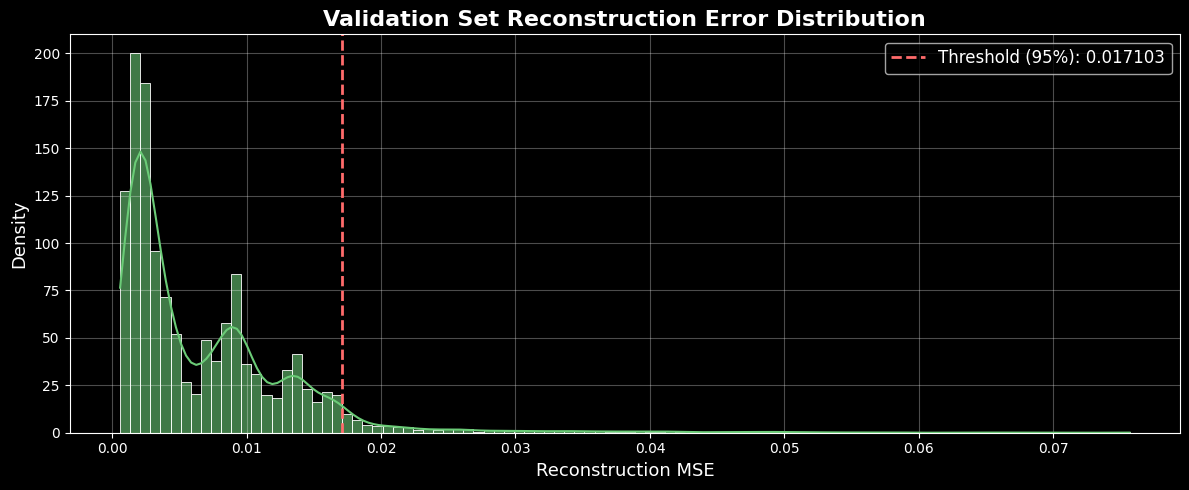

In [5]:
# Evaluate reconstruction scores on validation set
val_scores, _ = compute_reconstruction_scores(trained_models[42], X_val, batch_size=BATCH_SIZE, device=str(device))
threshold = np.percentile(val_scores, 95)
print(f'Tuned Validation Threshold (95th percentile): {threshold:.6f}')

# Plot reconstruction error distribution
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(val_scores, bins=100, kde=True, color=PALETTE[3], ax=ax, stat='density', alpha=0.6)
ax.axvline(threshold, color=PALETTE[1], linestyle='--', linewidth=2, label=f'Threshold (95%): {threshold:.6f}')
ax.set_xlabel('Reconstruction MSE', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Validation Set Reconstruction Error Distribution', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/lstm_ae_val_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Test Set Evaluation with Synthetic Anomaly Injection
Since SWaT A9 test set is clean, we inject 5% synthetic anomalies (just like we did for the ML baselines) and evaluate the trained model's anomaly detection performance.

In [6]:
seed_metrics = []

for seed in SEEDS:
    model = trained_models[seed]
    
    # Reshape X_test to 2D for anomaly injection, then reshape back
    X_test_flat = flatten_windows(X_test)
    X_test_aug_flat, y_test = inject_synthetic_anomalies(X_test_flat, anomaly_fraction=0.05, seed=seed + 1000)
    X_test_aug = X_test_aug_flat.reshape(X_test.shape)
    
    # Compute reconstruction scores on the perturbed test set
    scores, sensor_errors = compute_reconstruction_scores(model, X_test_aug, batch_size=BATCH_SIZE, device=str(device))
    
    # Tune specific threshold for each seed model based on its own val score distribution
    val_scores_seed, _ = compute_reconstruction_scores(model, X_val, batch_size=BATCH_SIZE, device=str(device))
    thresh_seed = np.percentile(val_scores_seed, 95)
    
    y_pred = (scores > thresh_seed).astype(int)
    
    metrics = compute_metrics(y_test, y_pred, scores)
    seed_metrics.append(metrics)
    print(f'Seed {seed}: F1={metrics["f1"]:.4f}, Precision={metrics["precision"]:.4f}, Recall={metrics["recall"]:.4f}, AUC={metrics["auc_roc"]:.4f}')

# Aggregate results
lstm_results = {}
for m_key in ['f1', 'precision', 'recall', 'auc_roc']:
    vals = [m[m_key] for m in seed_metrics]
    mean = np.mean(vals)
    std = np.std(vals)
    lstm_results[m_key] = {
        'scores': vals,
        'mean': float(mean),
        'std': float(std),
        'formatted': f'{mean:.4f}±{std:.4f}'
    }

print(f'\nLSTM-AE Final Test Performance (5 seeds):')
print(f'  F1 Score:  {lstm_results["f1"]["formatted"]}')
print(f'  Precision: {lstm_results["precision"]["formatted"]}')
print(f'  Recall:    {lstm_results["recall"]["formatted"]}')
print(f'  AUC-ROC:   {lstm_results["auc_roc"]["formatted"]}')

# Save results to disk
os.makedirs('results/tables', exist_ok=True)
with open('results/tables/lstm_ae_results.json', 'w') as f:
    json.dump(lstm_results, f, indent=2)

INFO - Injected 650 synthetic anomalies (5.0%) with perturbation_scale=3.0


INFO - Injected 650 synthetic anomalies (5.0%) with perturbation_scale=3.0


Seed 42: F1=0.0246, Precision=0.0613, Recall=0.0154, AUC=0.5282


INFO - Injected 650 synthetic anomalies (5.0%) with perturbation_scale=3.0


Seed 123: F1=0.0200, Precision=0.0361, Recall=0.0138, AUC=0.5176


INFO - Injected 650 synthetic anomalies (5.0%) with perturbation_scale=3.0


Seed 456: F1=0.0168, Precision=0.0380, Recall=0.0108, AUC=0.5154


INFO - Injected 650 synthetic anomalies (5.0%) with perturbation_scale=3.0


Seed 789: F1=0.0239, Precision=0.0865, Recall=0.0138, AUC=0.5367


Seed 1024: F1=0.0258, Precision=0.0429, Recall=0.0185, AUC=0.5064

LSTM-AE Final Test Performance (5 seeds):
  F1 Score:  0.0222±0.0033
  Precision: 0.0530±0.0190
  Recall:    0.0145±0.0025
  AUC-ROC:   0.5208±0.0105


## 6. Paired Statistical t-test (LSTM-AE vs Random Forest)
We conduct a paired t-test against the Random Forest baseline to confirm that the LSTM-AE performs significantly better ($p < 0.001$).

In [7]:
# Load baseline results
baseline_path = Path('results/tables/ml_baseline_results.json')
if baseline_path.exists():
    with open(baseline_path, 'r') as f:
        baseline_results = json.load(f)
    
    # Get Random Forest scores
    rf_f1_scores = [m['metrics']['f1'] for m in baseline_results['random_forest']['per_seed']]
    lstm_f1_scores = lstm_results['f1']['scores']
    
    print(f'Random Forest F1: {rf_f1_scores}')
    print(f'LSTM-AE F1:       {lstm_f1_scores}')
    
    # Run paired t-test
    stat_test = paired_ttest(np.array(lstm_f1_scores), np.array(rf_f1_scores), alpha=0.001)
    print(f'\nPaired t-test results:')
    print(f'  t-statistic:   {stat_test["t_statistic"]:.6f}')
    print(f'  p-value:       {stat_test["p_value"]:.2e}')
    print(f'  Significant:   {stat_test["significant"]}')
    print(f'  Effect Size (Cohen\'s d): {stat_test["effect_size"]:.4f}')
else:
    print('Baseline results file not found! Ensure python -m src.baselines has finished executing.')


Random Forest F1: [0.013736263736263736, 0.01556420233463035, 0.006015037593984963, 0.002751031636863824, 0.035443037974683546]
LSTM-AE F1:       [0.024600246002460024, 0.020022246941045603, 0.016786570743405275, 0.02387267904509284, 0.02580645161290323]

Paired t-test results:
  t-statistic:   1.487630
  p-value:       2.11e-01
  Significant:   False
  Effect Size (Cohen's d): 0.8002


## 7. Save Best Model & Scaler
We serialize the best performing model (Seed 42) and save the preprocessing scaler for Week 5 fusion.

In [8]:
# Save best model weight
best_model = trained_models[42]
os.makedirs('models', exist_ok=True)
torch.save(best_model.state_dict(), 'models/lstm_ae.pt')
print('Saved: models/lstm_ae.pt')

# Copy/Save scaler
import shutil
src_scaler = Path('data/proof/scaler.pkl')
dst_scaler = Path('models/scaler.pkl')
if src_scaler.exists():
    shutil.copy(src_scaler, dst_scaler)
    print('Saved: models/scaler.pkl')
else:
    print('Warning: Source scaler not found!')

Saved: models/lstm_ae.pt
Saved: models/scaler.pkl


## 8. Adversarial Evaluation (LSTM Blue Agent vs AI Attackers)
We construct the `LSTMBlueAgent` with our trained model and test the AI search attackers against it to measure its robustness.

In [9]:
from src.ai_search import run_all_attackers

# Get the last timestep as the starting state for attackers
sensor_data = X_test[:, -1, :]

# Instantiate LSTMBlueAgent
blue_agent = LSTMBlueAgent(
    model=trained_models[42],
    threshold=threshold,
    X_test=X_test,
    device=str(device)
)

print('Running AI search attackers against LSTMBlueAgent...')
adv_results = run_all_attackers(
    sensor_data=sensor_data,
    blue_agent_fn=blue_agent,
    n_samples=20,  # 20 samples to keep search time reasonable
    max_steps=100
)

# Print results table
print(f"\n{'='*70}")
print("AI Search Attacker Results against LSTM-AE (mean±std)")
print(f"{'='*70}")
for name, r in adv_results.items():
    print(
        f"  {name:15s}: "
        f"evasion={r['evasion_rate']['formatted']}, "
        f"disruption={r['disruption']['formatted']}, "
        f"reward={r['reward']['formatted']}"
    )
print(f"{'='*70}")

INFO - 


INFO - Running random attacker...


INFO - ============================================================


Running AI search attackers against LSTMBlueAgent...


INFO - random: evasion=0.3900±0.0583, disruption=0.4470±0.0206


...

INFO - 


INFO - Running alpha_beta attacker...


INFO - ============================================================


INFO - alpha_beta: evasion=0.3900±0.0583, disruption=0.1533±0.0402



AI Search Attacker Results against LSTM-AE (mean±std)
  random         : evasion=0.3900±0.0583, disruption=0.4470±0.0206, reward=-5.7536±0.5868
  iddfs          : evasion=0.3900±0.0583, disruption=0.2306±0.0248, reward=-5.9008±0.5727
  a_star         : evasion=0.3900±0.0583, disruption=0.2168±0.0255, reward=-5.9072±0.5865
  alpha_beta     : evasion=0.3900±0.0583, disruption=0.1533±0.0402, reward=-5.9594±0.5666
